#**Importing image files in train folder from google drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Checking how many files are presrent in each imported folder**

In [2]:
import os

TRAIN_DIR = '/content/drive/MyDrive/Semicon Hackathon/train'

for root, dirs, files in os.walk(TRAIN_DIR):
    level = root.replace(TRAIN_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/  ({len(files)} files)')

train/  (1 files)
  GT/  (3203 files)
  NoisyLR/  (3200 files)


#**Checking the shape and size of image files**

In [3]:
import numpy as np
import matplotlib.pyplot as plt

GT_DIR = '/content/drive/MyDrive/Semicon Hackathon/train/GT'
NOISY_DIR = '/content/drive/MyDrive/Semicon Hackathon/train/NoisyLR'

# Get sorted list of .npy filenames (filter out any non-npy stragglers)
gt_files = sorted(f for f in os.listdir(GT_DIR) if f.endswith('.npy'))
noisy_files = sorted(f for f in os.listdir(NOISY_DIR) if f.endswith('.npy'))

print(f"GT: {len(gt_files)} npy files | NoisyLR: {len(noisy_files)} npy files")

# Check first array's shape/dtype to know how to display it
sample_gt = np.load(os.path.join(GT_DIR, gt_files[0]))
sample_noisy = np.load(os.path.join(NOISY_DIR, noisy_files[0]))
print("GT shape:", sample_gt.shape, sample_gt.dtype)
print("NoisyLR shape:", sample_noisy.shape, sample_noisy.dtype)

GT: 3203 npy files | NoisyLR: 3200 npy files
GT shape: (256, 256) float32
NoisyLR shape: (128, 128) float32


# **Plotting the first five images and comparing them**

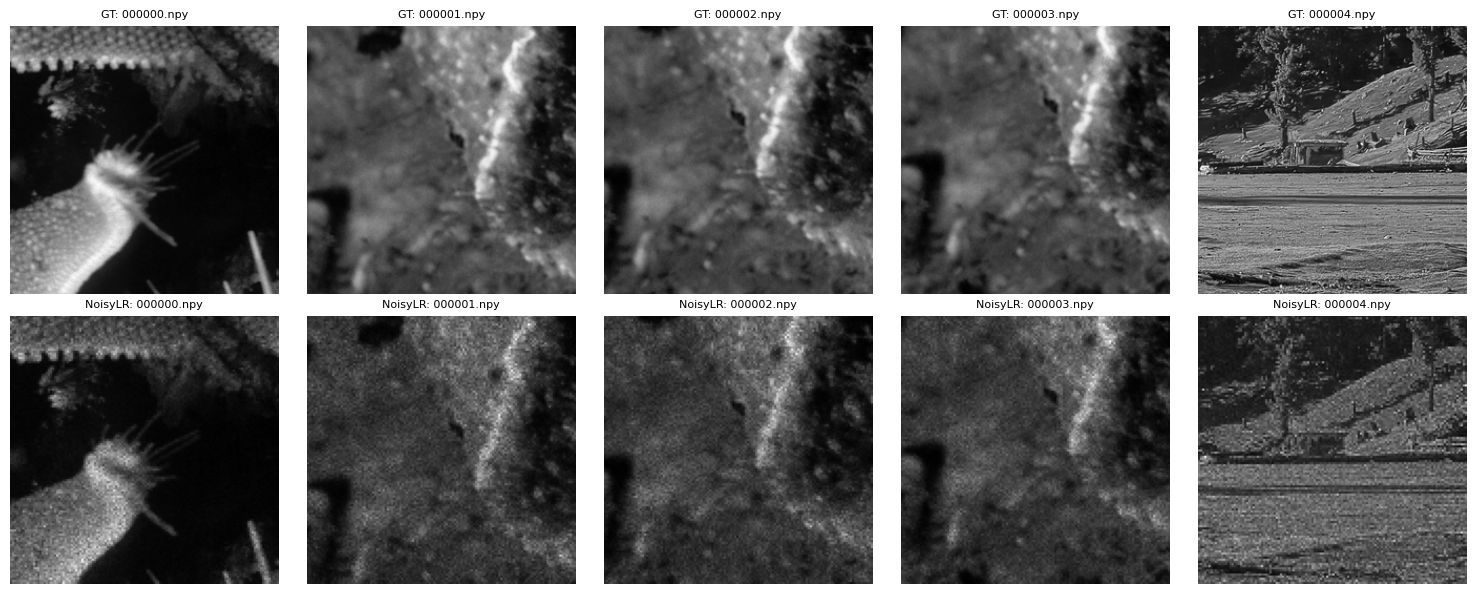

In [4]:
n = 5
fig, axes = plt.subplots(2, n, figsize=(3*n, 6))

for i in range(n):
    gt = np.load(os.path.join(GT_DIR, gt_files[i]))
    noisy = np.load(os.path.join(NOISY_DIR, noisy_files[i]))

    # If channel-first (C,H,W) with 3 channels, convert to (H,W,C) for imshow
    if gt.ndim == 3 and gt.shape[0] in (1, 3):
        gt = np.transpose(gt, (1, 2, 0))
    if noisy.ndim == 3 and noisy.shape[0] in (1, 3):
        noisy = np.transpose(noisy, (1, 2, 0))

    # Squeeze single-channel to 2D for imshow with cmap
    gt_disp = gt.squeeze()
    noisy_disp = noisy.squeeze()

    axes[0, i].imshow(gt_disp, cmap='gray' if gt_disp.ndim == 2 else None)
    axes[0, i].set_title(f'GT: {gt_files[i]}', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy_disp, cmap='gray' if noisy_disp.ndim == 2 else None)
    axes[1, i].set_title(f'NoisyLR: {noisy_files[i]}', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# **Checking the Shape and the range of the image files**

In [5]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

GT_DIR = '/content/drive/MyDrive/Semicon Hackathon/train/GT'
NOISY_DIR = '/content/drive/MyDrive/Semicon Hackathon/train/NoisyLR'

gt_files = sorted(f for f in os.listdir(GT_DIR) if f.endswith('.npy'))
noisy_files = sorted(f for f in os.listdir(NOISY_DIR) if f.endswith('.npy'))

In [6]:
sample_gt = np.load(os.path.join(GT_DIR, gt_files[0]))
sample_noisy = np.load(os.path.join(NOISY_DIR, noisy_files[0]))
print("GT range:", sample_gt.min(), sample_gt.max(), sample_gt.dtype)
print("Noisy range:", sample_noisy.min(), sample_noisy.max(), sample_noisy.dtype)

GT range: 0.0 1.0 float32
Noisy range: -0.0026427102 1.3257757 float32


In [7]:
gt = np.load(os.path.join(GT_DIR, gt_files[0]))
noisy = np.load(os.path.join(NOISY_DIR, noisy_files[0]))
print("GT shape:", gt.shape)
print("NoisyLR shape:", noisy.shape)

GT shape: (256, 256)
NoisyLR shape: (128, 128)


#**Since the GT and Noisy images are of 256x256 and 128x128 respectively, we resize and compare the images and find their PSNR and SSIM scores**


In [8]:
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

data_range = 255  # adjust based on your value-range check

for i in range(5):
    gt = np.load(os.path.join(GT_DIR, gt_files[i])).astype(np.float64)
    noisy = np.load(os.path.join(NOISY_DIR, noisy_files[i])).astype(np.float64)

    # Upsample noisy to match GT's shape
    noisy_resized = resize(noisy, gt.shape, order=3, preserve_range=True, anti_aliasing=True)

    p = psnr(gt, noisy_resized, data_range=data_range)
    s = ssim(gt, noisy_resized, data_range=data_range)

    print(f"{gt_files[i]}  |  GT shape: {gt.shape}  NoisyLR shape: {noisy.shape}  |  PSNR: {p:.2f} dB  |  SSIM: {s:.4f}")

000000.npy  |  GT shape: (256, 256)  NoisyLR shape: (128, 128)  |  PSNR: 75.07 dB  |  SSIM: 0.9999
000001.npy  |  GT shape: (256, 256)  NoisyLR shape: (128, 128)  |  PSNR: 73.30 dB  |  SSIM: 0.9999
000002.npy  |  GT shape: (256, 256)  NoisyLR shape: (128, 128)  |  PSNR: 74.37 dB  |  SSIM: 0.9999
000003.npy  |  GT shape: (256, 256)  NoisyLR shape: (128, 128)  |  PSNR: 75.56 dB  |  SSIM: 0.9999
000004.npy  |  GT shape: (256, 256)  NoisyLR shape: (128, 128)  |  PSNR: 67.62 dB  |  SSIM: 0.9997


In [9]:
import torch
import torch.nn as nn

class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        x = self.act(self.conv1(x))
        x = self.conv2(x)
        return self.act(x + residual)

class RestorationNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, num_res_blocks=8, scale=2):
        super().__init__()
        self.head = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        self.body = nn.Sequential(*[ResBlock(base_channels) for _ in range(num_res_blocks)])
        self.body_out = nn.Conv2d(base_channels, base_channels, 3, padding=1)

        # Pixel-shuffle upsampling: conv to (channels * scale^2), then rearrange
        self.upsample = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * (scale ** 2), 3, padding=1),
            nn.PixelShuffle(scale),
            nn.ReLU(inplace=True),
        )
        self.tail = nn.Conv2d(base_channels, in_channels, 3, padding=1)

    def forward(self, x):
        feat = self.head(x)
        body_feat = self.body_out(self.body(feat))
        feat = feat + body_feat          # global residual within feature space
        up = self.upsample(feat)
        out = self.tail(up)
        return torch.clamp(out, 0.0, 1.0)  # enforce GT's known [0,1] range

#Running with CPU

In [10]:
model = RestorationNet()
x = torch.randn(4, 1, 128, 128)  # batch of 4, matching your NoisyLR shape
y = model(x)
print(y.shape)  # should print torch.Size([4, 1, 256, 256])

# param count and rough speed check
n_params = sum(p.numel() for p in model.parameters())
print(f"Params: {n_params/1e6:.2f}M")

import time
model.eval()
with torch.no_grad():
    start = time.time()
    for _ in range(20):
        _ = model(x)
    print(f"Avg time per batch-of-4 (CPU): {(time.time()-start)/20*1000:.1f} ms")

torch.Size([4, 1, 256, 256])
Params: 0.78M
Avg time per batch-of-4 (CPU): 1756.4 ms


#Running with GPU

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = RestorationNet().to(device)
x = torch.randn(4, 1, 128, 128).to(device)

model.eval()
with torch.no_grad():
    # warm-up run (first GPU call is always slower due to kernel compilation)
    _ = model(x)
    torch.cuda.synchronize()

    start = time.time()
    for _ in range(20):
        _ = model(x)
    torch.cuda.synchronize()
    print(f"Avg time per batch-of-4 (GPU): {(time.time()-start)/20*1000:.2f} ms")

cuda
Avg time per batch-of-4 (GPU): 28.51 ms


#Everything ordered

In [16]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

##Paths

In [17]:
GT_DIR = '/content/drive/MyDrive/Semicon Hackathon/train/GT'
NOISY_DIR = '/content/drive/MyDrive/Semicon Hackathon/train/NoisyLR'
CHECKPOINT_DIR = '/content/drive/MyDrive/Semicon Hackathon/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

##Dataset Class

In [18]:
class RestorationDataset(Dataset):
    def __init__(self, gt_dir, noisy_dir, augment=False):
        self.gt_dir = gt_dir
        self.noisy_dir = noisy_dir
        gt_set = set(f for f in os.listdir(gt_dir) if f.endswith('.npy'))
        noisy_set = set(f for f in os.listdir(noisy_dir) if f.endswith('.npy'))
        self.files = sorted(gt_set & noisy_set)
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        gt = np.load(os.path.join(self.gt_dir, fname)).astype(np.float32)
        noisy = np.load(os.path.join(self.noisy_dir, fname)).astype(np.float32)

        gt = torch.from_numpy(gt).unsqueeze(0)
        noisy = torch.from_numpy(noisy).unsqueeze(0)

        if self.augment:
            if torch.rand(1).item() < 0.5:
                gt = torch.flip(gt, dims=[-1])
                noisy = torch.flip(noisy, dims=[-1])
            if torch.rand(1).item() < 0.5:
                gt = torch.flip(gt, dims=[-2])
                noisy = torch.flip(noisy, dims=[-2])
            k = torch.randint(0, 4, (1,)).item()
            if k > 0:
                gt = torch.rot90(gt, k, dims=[-2, -1])
                noisy = torch.rot90(noisy, k, dims=[-2, -1])

        return noisy, gt

##Model Class

In [19]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        x = self.act(self.conv1(x))
        x = self.conv2(x)
        return self.act(x + residual)

class RestorationNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, num_res_blocks=8, scale=2):
        super().__init__()
        self.head = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        self.body = nn.Sequential(*[ResBlock(base_channels) for _ in range(num_res_blocks)])
        self.body_out = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.upsample = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * (scale ** 2), 3, padding=1),
            nn.PixelShuffle(scale),
            nn.ReLU(inplace=True),
        )
        self.tail = nn.Conv2d(base_channels, in_channels, 3, padding=1)

    def forward(self, x):
        feat = self.head(x)
        body_feat = self.body_out(self.body(feat))
        feat = feat + body_feat
        up = self.upsample(feat)
        out = self.tail(up)
        return torch.clamp(out, 0.0, 1.0)

##Loss Function

In [20]:
def sobel_gradients(img):
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32, device=img.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32, device=img.device).view(1, 1, 3, 3)
    grad_x = F.conv2d(img, sobel_x, padding=1)
    grad_y = F.conv2d(img, sobel_y, padding=1)
    return grad_x, grad_y

def restoration_loss(pred, target, edge_weight=0.5):
    l1 = F.l1_loss(pred, target)
    pred_gx, pred_gy = sobel_gradients(pred)
    target_gx, target_gy = sobel_gradients(target)
    edge_loss = F.l1_loss(pred_gx, target_gx) + F.l1_loss(pred_gy, target_gy)
    return l1 + edge_weight * edge_loss

##Device + data split

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

full_dataset_noaug = RestorationDataset(GT_DIR, NOISY_DIR, augment=False)
n = len(full_dataset_noaug)
val_size = int(0.1 * n)
train_size = n - val_size

indices = torch.randperm(n).tolist()
train_idx, val_idx = indices[:train_size], indices[train_size:]

train_dataset_aug = RestorationDataset(GT_DIR, NOISY_DIR, augment=True)

train_dataset = Subset(train_dataset_aug, train_idx)
val_dataset = Subset(full_dataset_noaug, val_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

cuda
Train: 2880 | Val: 320


##Model, optimizer, scheduler, resume check

In [22]:
model = RestorationNet(base_channels=64, num_res_blocks=8).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 25
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

start_epoch = 0
best_val_psnr = 0.0

checkpoint_path = os.path.join(CHECKPOINT_DIR, 'latest_checkpoint.pth')

if os.path.exists(checkpoint_path):
    print("Found existing checkpoint — resuming...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_psnr = checkpoint['best_val_psnr']
    print(f"Resumed at epoch {start_epoch}, best PSNR so far: {best_val_psnr:.2f}")
else:
    print("No checkpoint found — starting fresh.")

No checkpoint found — starting fresh.


##Training loop (run this; re-run this same cell if disconnected)

In [26]:
for epoch in range(start_epoch, num_epochs):
    model.train()
    train_loss = 0.0
    batch_start = time.time()

    for batch_idx, (noisy, gt) in enumerate(train_loader):
        noisy, gt = noisy.to(device), gt.to(device)
        optimizer.zero_grad()
        pred = model(noisy)
        loss = restoration_loss(pred, gt)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * noisy.size(0)

        if batch_idx % 20 == 0:
            elapsed = time.time() - batch_start
            print(f"  Epoch {epoch+1}, batch {batch_idx}/{len(train_loader)} | elapsed: {elapsed:.1f}s")

    train_loss /= len(train_dataset)
    scheduler.step()

    model.eval()
    val_psnr, val_ssim = [], []
    with torch.no_grad():
        for noisy, gt in val_loader:
            noisy, gt = noisy.to(device), gt.to(device)
            pred = model(noisy)
            pred_np = pred.cpu().numpy()
            gt_np = gt.cpu().numpy()
            for i in range(pred_np.shape[0]):
                val_psnr.append(psnr_metric(gt_np[i, 0], pred_np[i, 0], data_range=1.0))
                val_ssim.append(ssim_metric(gt_np[i, 0], pred_np[i, 0], data_range=1.0))

    mean_psnr = np.mean(val_psnr)
    mean_ssim = np.mean(val_ssim)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val PSNR: {mean_psnr:.2f} dB | Val SSIM: {mean_ssim:.4f}")

    if mean_psnr > best_val_psnr:
        best_val_psnr = mean_psnr
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
        print(f"  -> Saved new best model (PSNR: {mean_psnr:.2f})")

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_psnr': best_val_psnr,
    }, os.path.join(CHECKPOINT_DIR, 'latest_checkpoint.pth'))

  Epoch 1, batch 0/180 | elapsed: 3.9s


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78615e69ec00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78615e69ec00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 1, batch 20/180 | elapsed: 34.6s
  Epoch 1, batch 40/180 | elapsed: 68.6s
  Epoch 1, batch 60/180 | elapsed: 102.1s
  Epoch 1, batch 80/180 | elapsed: 137.1s
  Epoch 1, batch 100/180 | elapsed: 171.1s
  Epoch 1, batch 120/180 | elapsed: 202.0s
  Epoch 1, batch 140/180 | elapsed: 229.1s
  Epoch 1, batch 160/180 | elapsed: 261.4s


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78615e69ec00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78615e69ec00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 1/25 | Train Loss: 0.1834 | Val PSNR: 27.20 dB | Val SSIM: 0.7197
  -> Saved new best model (PSNR: 27.20)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78615e69ec00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x78615e69ec00>    
if w.is_alive():Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

      self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
 if w.is_alive():      
^ ^^ ^^ ^ ^ ^ ^^ ^^^^
^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^^  ^ ^ ^ 
   File "/usr/lib

  Epoch 2, batch 0/180 | elapsed: 0.9s
  Epoch 2, batch 20/180 | elapsed: 8.2s
  Epoch 2, batch 40/180 | elapsed: 16.0s
  Epoch 2, batch 60/180 | elapsed: 23.7s
  Epoch 2, batch 80/180 | elapsed: 30.9s
  Epoch 2, batch 100/180 | elapsed: 37.9s
  Epoch 2, batch 120/180 | elapsed: 44.8s
  Epoch 2, batch 140/180 | elapsed: 51.7s
  Epoch 2, batch 160/180 | elapsed: 58.6s


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78615e69ec00><function _MultiProcessingDataLoaderIter.__del__ at 0x78615e69ec00>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()    
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

    if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

     if w.is_alive():
            ^ ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3

Epoch 2/25 | Train Loss: 0.1655 | Val PSNR: 27.43 dB | Val SSIM: 0.7260
  -> Saved new best model (PSNR: 27.43)
  Epoch 3, batch 0/180 | elapsed: 0.8s
  Epoch 3, batch 20/180 | elapsed: 7.7s
  Epoch 3, batch 40/180 | elapsed: 14.6s
  Epoch 3, batch 60/180 | elapsed: 21.7s
  Epoch 3, batch 80/180 | elapsed: 29.0s
  Epoch 3, batch 100/180 | elapsed: 36.2s
  Epoch 3, batch 120/180 | elapsed: 43.3s
  Epoch 3, batch 140/180 | elapsed: 50.4s
  Epoch 3, batch 160/180 | elapsed: 57.3s
Epoch 3/25 | Train Loss: 0.1628 | Val PSNR: 27.53 dB | Val SSIM: 0.7337
  -> Saved new best model (PSNR: 27.53)
  Epoch 4, batch 0/180 | elapsed: 0.7s
  Epoch 4, batch 20/180 | elapsed: 7.6s
  Epoch 4, batch 40/180 | elapsed: 14.5s
  Epoch 4, batch 60/180 | elapsed: 21.5s
  Epoch 4, batch 80/180 | elapsed: 28.5s
  Epoch 4, batch 100/180 | elapsed: 35.5s
  Epoch 4, batch 120/180 | elapsed: 42.6s
  Epoch 4, batch 140/180 | elapsed: 49.6s
  Epoch 4, batch 160/180 | elapsed: 56.7s
Epoch 4/25 | Train Loss: 0.1616 | Va

##Load the best model and visualize predictions

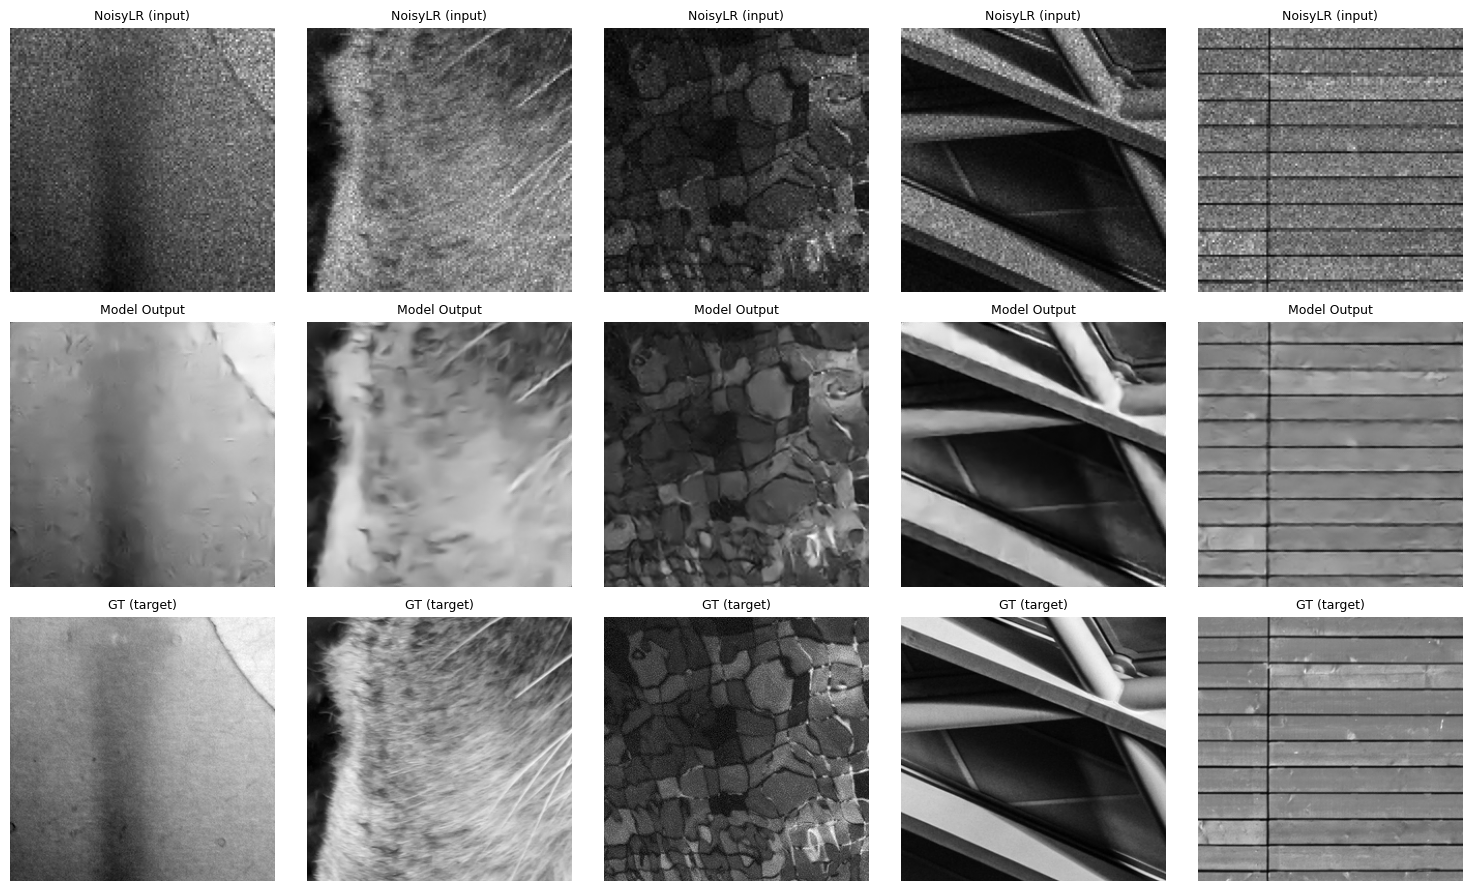

In [27]:
# Load best checkpoint
model = RestorationNet(base_channels=64, num_res_blocks=8).to(device)
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pth'), map_location=device))
model.eval()

import matplotlib.pyplot as plt

n = 5
fig, axes = plt.subplots(3, n, figsize=(3*n, 9))

with torch.no_grad():
    for i in range(n):
        noisy, gt = val_dataset[i]
        noisy_batch = noisy.unsqueeze(0).to(device)
        pred = model(noisy_batch).cpu().squeeze().numpy()

        noisy_np = noisy.squeeze().numpy()
        gt_np = gt.squeeze().numpy()

        axes[0, i].imshow(noisy_np, cmap='gray')
        axes[0, i].set_title('NoisyLR (input)', fontsize=9)
        axes[0, i].axis('off')

        axes[1, i].imshow(pred, cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title('Model Output', fontsize=9)
        axes[1, i].axis('off')

        axes[2, i].imshow(gt_np, cmap='gray', vmin=0, vmax=1)
        axes[2, i].set_title('GT (target)', fontsize=9)
        axes[2, i].axis('off')

plt.tight_layout()
plt.show()

##Compare against a naive baseline (bicubic upsample, no learning)

In [28]:
from skimage.transform import resize

baseline_psnr, baseline_ssim = [], []

for i in range(len(val_dataset)):
    noisy, gt = val_dataset[i]
    noisy_np = noisy.squeeze().numpy()
    gt_np = gt.squeeze().numpy()

    upsampled = resize(noisy_np, gt_np.shape, order=3, preserve_range=True, anti_aliasing=True)

    baseline_psnr.append(psnr_metric(gt_np, upsampled, data_range=1.0))
    baseline_ssim.append(ssim_metric(gt_np, upsampled, data_range=1.0))

print(f"Bicubic baseline — PSNR: {np.mean(baseline_psnr):.2f} dB | SSIM: {np.mean(baseline_ssim):.4f}")
print(f"Your model      — PSNR: 27.98 dB | SSIM: 0.7455")

Bicubic baseline — PSNR: 22.29 dB | SSIM: 0.5101
Your model      — PSNR: 27.98 dB | SSIM: 0.7455


In [30]:
def sobel_gradients(img):
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32, device=img.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32, device=img.device).view(1, 1, 3, 3)
    grad_x = F.conv2d(img, sobel_x, padding=1)
    grad_y = F.conv2d(img, sobel_y, padding=1)
    return grad_x, grad_y

def restoration_loss(pred, target, edge_weight=1.2):
    l1 = F.l1_loss(pred, target)
    pred_gx, pred_gy = sobel_gradients(pred)
    target_gx, target_gy = sobel_gradients(target)
    edge_loss = F.l1_loss(pred_gx, target_gx) + F.l1_loss(pred_gy, target_gy)
    return l1 + edge_weight * edge_loss